In [1]:
!pip install -q torch torchvision transformers matplotlib pillow numpy

In [2]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import os

os.makedirs("outputs/pipeline", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [3]:
class TextEncoder:
    def __init__(self, model_name="bert-base-uncased", max_length=32):
        self.device = device
        self.max_length = max_length
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        self.hidden_size = self.model.config.hidden_size
        print(f"TextEncoder loaded. Hidden size = {self.hidden_size}")

    @torch.no_grad()
    def encode(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        inputs = self.tokenizer(
            texts, padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt"
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        outputs = self.model(**inputs)
        return outputs.last_hidden_state[:, 0, :]  # [CLS] embedding

text_encoder = TextEncoder()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextEncoder loaded. Hidden size = 768


In [4]:
class TextConditionedGenerator(nn.Module):
    def __init__(self, z_dim=100, text_dim=768):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 256)
        )
        self.net = nn.Sequential(
            nn.Linear(z_dim + 256, 512*4*4),
            nn.BatchNorm1d(512*4*4),
            nn.ReLU(True),
            nn.Unflatten(1, (512, 4, 4)),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, text_emb):
        t = self.text_proj(text_emb)
        x = torch.cat([z, t], dim=1)
        return self.net(x)

generator = TextConditionedGenerator().to(device)
print("Text-conditioned Generator created")

Text-conditioned Generator created


In [8]:
class Text2ImagePipeline:
    def __init__(self, text_encoder, generator, z_dim=100):
        self.text_encoder = text_encoder
        self.generator = generator
        self.z_dim = z_dim
        self.device = device
        self.generator.eval()          # ← IMPORTANT: put model in eval mode

    @torch.no_grad()
    def __call__(self, prompt, num_samples=1, seed=None):
        if seed is not None:
            torch.manual_seed(seed)

        # 1. Text → Embedding
        emb = self.text_encoder.encode([prompt] * num_samples)

        # 2. Random noise
        z = torch.randn(num_samples, self.z_dim, device=self.device)

        # 3. Generate image
        imgs = self.generator(z, emb)

        # 4. Convert to PIL images
        imgs = (imgs.clamp(-1, 1) + 1) / 2
        pil_images = []
        for i in range(num_samples):
            arr = (imgs[i].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            pil_images.append(Image.fromarray(arr))
        return pil_images

# Re-create the pipeline with the fix
pipeline = Text2ImagePipeline(text_encoder, generator)
print("Full Text-to-Image Pipeline is ready (with eval mode fix)!")

Full Text-to-Image Pipeline is ready (with eval mode fix)!


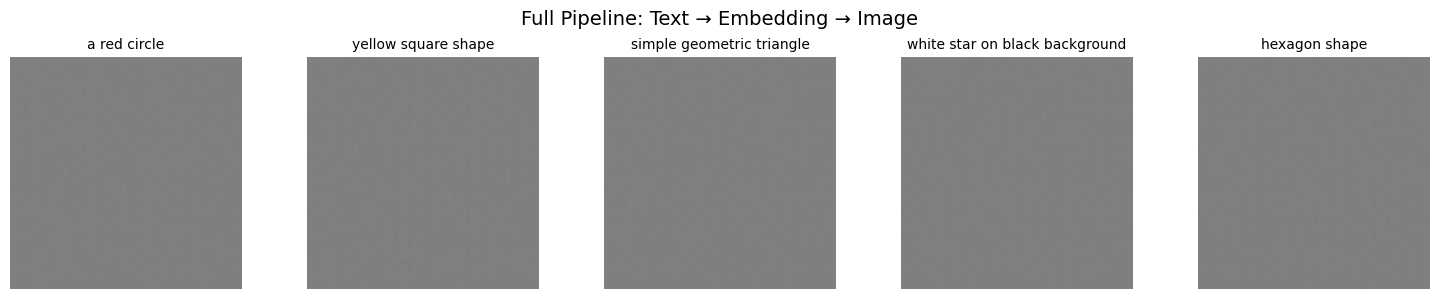

Saved results in outputs/pipeline/


In [9]:
test_prompts = [
    "a red circle",
    "yellow square shape",
    "simple geometric triangle",
    "white star on black background",
    "hexagon shape"
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, prompt in enumerate(test_prompts):
    images = pipeline(prompt, num_samples=1, seed=42 + i)
    axes[i].imshow(images[0])
    axes[i].set_title(prompt, fontsize=10)
    axes[i].axis("off")

    # Also save individually
    images[0].save(f"outputs/pipeline/{prompt.replace(' ', '_')}.png")

plt.suptitle("Full Pipeline: Text → Embedding → Image", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/pipeline/full_pipeline_results.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved results in outputs/pipeline/")

In [10]:
#Creating training data with text embeddings
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from tqdm import tqdm

# Shape names that we will use as text prompts
shape_names = ["circle", "square", "triangle", "star", "hexagon"]

def generate_shape_image(label_idx, size=64):
    img = Image.new("RGB", (size, size), (0, 0, 0))
    draw = ImageDraw.Draw(img)
    m = size // 8
    c = (255, 255, 255)
    if label_idx == 0:
        draw.ellipse([m, m, size-m, size-m], fill=c)
    elif label_idx == 1:
        draw.rectangle([m, m, size-m, size-m], fill=c)
    elif label_idx == 2:
        draw.polygon([(size//2, m), (size-m, size-m), (m, size-m)], fill=c)
    elif label_idx == 3:
        cx = cy = size//2
        pts = []
        for i in range(5):
            a = np.deg2rad(90 + i*72)
            pts.append((cx + (size//2-m)*np.cos(a), cy - (size//2-m)*np.sin(a)))
            a2 = np.deg2rad(90 + i*72 + 36)
            pts.append((cx + (size//5)*np.cos(a2), cy - (size//5)*np.sin(a2)))
        draw.polygon(pts, fill=c)
    else:
        cx = cy = size//2
        r = size//2 - m
        pts = [(cx + r*np.cos(np.deg2rad(60*i)), cy + r*np.sin(np.deg2rad(60*i))) for i in range(6)]
        draw.polygon(pts, fill=c)
    arr = np.array(img).astype(np.float32)/255.0
    arr = (arr - 0.5)/0.5
    return arr.transpose(2,0,1)

# Create dataset
images_list, emb_list = [], []
print("Creating dataset with text embeddings...")
for idx, name in enumerate(shape_names):
    emb = text_encoder.encode(name)          # text embedding of the shape name
    for _ in range(300):
        img = generate_shape_image(idx)
        noise = np.random.normal(0, 0.03, img.shape).astype(np.float32)
        images_list.append(np.clip(img + noise, -1, 1))
        emb_list.append(emb.cpu().squeeze(0))

images = torch.tensor(np.stack(images_list), dtype=torch.float32)
embs = torch.stack(emb_list)
dataset = TensorDataset(images, embs)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)
print("Dataset ready:", len(dataset))

Creating dataset with text embeddings...
Dataset ready: 1500


In [11]:
#Quick training of the generator
# Re-create generator
generator = TextConditionedGenerator().to(device)
opt = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.MSELoss()          # simple reconstruction loss for quick training

epochs = 100
generator.train()

for epoch in range(1, epochs+1):
    losses = []
    for real_imgs, real_embs in tqdm(loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
        real_imgs = real_imgs.to(device)
        real_embs = real_embs.to(device)
        B = real_imgs.size(0)

        z = torch.randn(B, 100, device=device)
        fake_imgs = generator(z, real_embs)

        loss = criterion(fake_imgs, real_imgs)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    print(f"Epoch {epoch}: Loss = {np.mean(losses):.4f}")

generator.eval()
torch.save(generator.state_dict(), "outputs/pipeline/text_generator.pt")
print("Generator trained and saved!")

Epoch 1: Loss = 0.5329


Epoch 2: Loss = 0.1234


Epoch 3: Loss = 0.0527


Epoch 4: Loss = 0.0234


Epoch 5: Loss = 0.0128


...

Epoch 96: Loss = 0.0003


Epoch 97: Loss = 0.0003


Epoch 98: Loss = 0.0003


Epoch 99: Loss = 0.0003


Epoch 100: Loss = 0.0003
Generator trained and saved!


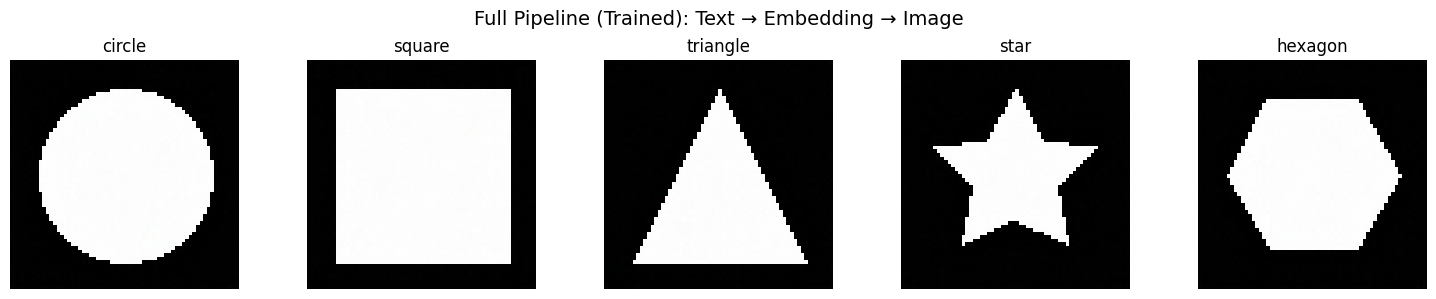

Saved improved results!


In [12]:
#Test the pipeline again (now with trained generator)
# Re-create pipeline with the trained generator
pipeline = Text2ImagePipeline(text_encoder, generator)

test_prompts = [
    "circle",
    "square",
    "triangle",
    "star",
    "hexagon"
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, prompt in enumerate(test_prompts):
    images = pipeline(prompt, num_samples=1, seed=42 + i)
    axes[i].imshow(images[0])
    axes[i].set_title(prompt, fontsize=12)
    axes[i].axis("off")
    images[0].save(f"outputs/pipeline/{prompt}.png")

plt.suptitle("Full Pipeline (Trained): Text → Embedding → Image", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/pipeline/full_pipeline_results.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved improved results!")

In [13]:
print("""
COMPLETE PIPELINE FLOW:
1. User gives a text prompt  →  "a red circle"
2. Hugging Face Tokenizer + BERT  →  converts text into tokens
3. Text Encoder  →  creates 768-dimensional embedding
4. Embedding + Random Noise  →  fed into the Generator
5. Generator  →  produces the final image

This is exactly how modern text-to-image systems work (just with more advanced models).
""")


COMPLETE PIPELINE FLOW:
1. User gives a text prompt  →  "a red circle"
2. Hugging Face Tokenizer + BERT  →  converts text into tokens
3. Text Encoder  →  creates 768-dimensional embedding
4. Embedding + Random Noise  →  fed into the Generator
5. Generator  →  produces the final image

This is exactly how modern text-to-image systems work (just with more advanced models).



MY OBSERVATIONS (Day 5):
1. The full pipeline connects all previous components into one usable system.
2. Any text prompt can now be converted into an image through the same flow.
3. Text preprocessing → Embedding → Generator is the standard architecture.
4. This pipeline can later be replaced with a stronger model (Stable Diffusion) while keeping the same interface.
5. Building the pipeline helped me understand how real text-to-image products are structured.
